# EmporiUm Sales Territory Analysis
## Capstone 2 Business Analysis with Python

Analyst - Hana Merawi

# Sales Territories Analyzed
Massachusetts - Territory Manager Bo Heap

Maryland - Territory Manager Shruti Reddy

Region - Northeast |    Region Director - Michael Jarvis

Data Period - January 2022 – September 2025

This notebook walks through a full marketing analysis of in-store sales data for the Massachusetts and Maryland territories of EmporiUm, a student bookstore chain. The analysis covers store performance, customer behavior, product category trends and a final marketing recommendation

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load Data Files

In [2]:
# StoreSales all in-store transactions
store_sales = pd.read_csv('StoreSales.csv')
store_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


In [3]:
# StoreDetail store locations, territories, and regions
store_detail = pd.read_csv('StoreDetail.csv')
store_detail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


In [4]:
# Products product catalog with category references
products = pd.read_csv('Products.csv')
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


In [5]:
# ProductCategories category and subcategory names
product_categories = pd.read_csv('ProductCategories.csv')
product_categories.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


In [6]:
# customer_list rewards members 
customer_list = pd.read_csv('customer_list.csv', sep='|')
customer_list.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


## Data Preparation

In [7]:
# Convert Transaction Date to datetime
store_sales['Transaction Date'] = pd.to_datetime(store_sales['Transaction Date'])

# Add Month and Year columns for time based grouping
store_sales['Month'] = store_sales['Transaction Date'].dt.to_period('M')
store_sales['Year'] = store_sales['Transaction Date'].dt.year

# Filter stores for Massachusetts and Maryland territories
territory_stores = store_detail[store_detail['State'].isin(['Massachusetts', 'Maryland'])].copy()
territory_ids = territory_stores['Store ID'].tolist()

# Filter sales to my two territories
territory_sales = store_sales[store_sales['Store ID'].isin(territory_ids)].copy()

print(f'Total territory transactions: {len(territory_sales):,}')
print(f'Date range: {territory_sales["Transaction Date"].min().date()} to {territory_sales["Transaction Date"].max().date()}')
print(f'Stores in territory: {territory_sales["Store ID"].nunique()}')

Total territory transactions: 131,476
Date range: 2022-01-01 to 2025-12-31
Stores in territory: 27


## Core Marketing Analysis

### Question 1 Territory Managers, Store IDs, and Cities

Who are the territory managers for each assigned territory? What are the store IDs and cities for each store?

In [8]:
# Massachusetts stores
ma_stores = territory_stores[territory_stores['State'] == 'Massachusetts'][['Store ID', 'Store Location', 'Territory Manager', 'Region', 'Region Director']]
print('MASSACHUSETTS')
print(ma_stores.to_string(index=False))

MASSACHUSETTS
 Store ID Store Location Territory Manager    Region Region Director
      730         Boston           Bo Heap Northeast  Michael Jarvis
      801      Attleboro           Bo Heap Northeast  Michael Jarvis
      802       Falmouth           Bo Heap Northeast  Michael Jarvis
      803     Framingham           Bo Heap Northeast  Michael Jarvis
      804      Haverhill           Bo Heap Northeast  Michael Jarvis
      805        Hingham           Bo Heap Northeast  Michael Jarvis
      806        Holyoke           Bo Heap Northeast  Michael Jarvis
      807     Leominster           Bo Heap Northeast  Michael Jarvis
      808         Lowell           Bo Heap Northeast  Michael Jarvis
      809           Lynn           Bo Heap Northeast  Michael Jarvis
      810      Nantucket           Bo Heap Northeast  Michael Jarvis
      811    New Bedford           Bo Heap Northeast  Michael Jarvis
      812    Northampton           Bo Heap Northeast  Michael Jarvis
      813     Pittsf

In [9]:
# Maryland stores
md_stores = territory_stores[territory_stores['State'] == 'Maryland'][['Store ID', 'Store Location', 'Territory Manager', 'Region', 'Region Director']]
print('MARYLAND')
print(md_stores.to_string(index=False))

MARYLAND
 Store ID      Store Location Territory Manager    Region Region Director
      731           Annapolis      Shruti Reddy Northeast  Michael Jarvis
      732          Back River      Shruti Reddy Northeast  Michael Jarvis
      733           Baltimore      Shruti Reddy Northeast  Michael Jarvis
      734          Germantown      Shruti Reddy Northeast  Michael Jarvis
      735              Howard      Shruti Reddy Northeast  Michael Jarvis
      736       North Harford      Shruti Reddy Northeast  Michael Jarvis
      737           Parkville      Shruti Reddy Northeast  Michael Jarvis
      738 Queen Anne's County      Shruti Reddy Northeast  Michael Jarvis
      739             Ridgely      Shruti Reddy Northeast  Michael Jarvis


### Result
- Massachusetts - 18 stores (Store IDs 730, 801–817), managed by Bo Heap, Region - Northeast
- Maryland 9 stores (Store IDs 731–739), managed by Shruti Reddy, Region - Northeast
- Both territories fall under Region Director Michael Jarvis

### Question 2 Monthly Total Revenue by Territory

What is the monthly total revenue for in-store sales in each territory over the full data period?

In [10]:
# Merge sales with store state info
sales_with_state = territory_sales.merge(
    territory_stores[['Store ID', 'State']], on='Store ID'
)

# Group by Month and State
monthly_revenue = sales_with_state.groupby(['Month', 'State'])['Sale Amount'].sum().reset_index()
monthly_revenue.columns = ['Month', 'State', 'Total Revenue']

# Pivot for readability
monthly_pivot = monthly_revenue.pivot(index='Month', columns='State', values='Total Revenue').reset_index()
monthly_pivot.columns.name = None
monthly_pivot['Month'] = monthly_pivot['Month'].astype(str)
print(monthly_pivot.to_string(index=False))

  Month  Maryland  Massachusetts
2022-01 190064.90       69396.42
2022-02 197529.18       65616.00
2022-03 210228.48       77390.00
2022-04 179004.18       81333.60
2022-05 212028.70       75919.64
2022-06 198318.98       81227.82
2022-07 231208.13       67271.23
2022-08 203503.40       73543.48
2022-09 158952.74       58716.74
2022-10 200423.07       72514.81
2022-11 202365.13       70654.73
2022-12 226340.81       70025.64
2023-01 247207.80      139388.56
2023-02 215146.55      104454.67
2023-03 212397.10      112443.92
2023-04 253354.48      109369.00
2023-05 236271.38      109021.42
2023-06 243603.42      101710.16
2023-07 218664.85      120793.96
2023-08 233256.77      126212.14
2023-09 227638.37      121968.93
2023-10 248095.23      113824.37
2023-11 242019.94      105670.08
2023-12 236037.31      101641.22
2024-01 234650.29      117915.05
2024-02 200891.75      103968.70
2024-03 263664.98      110968.54
2024-04 225960.88      107421.88
2024-05 248901.48      106193.39
2024-06 21

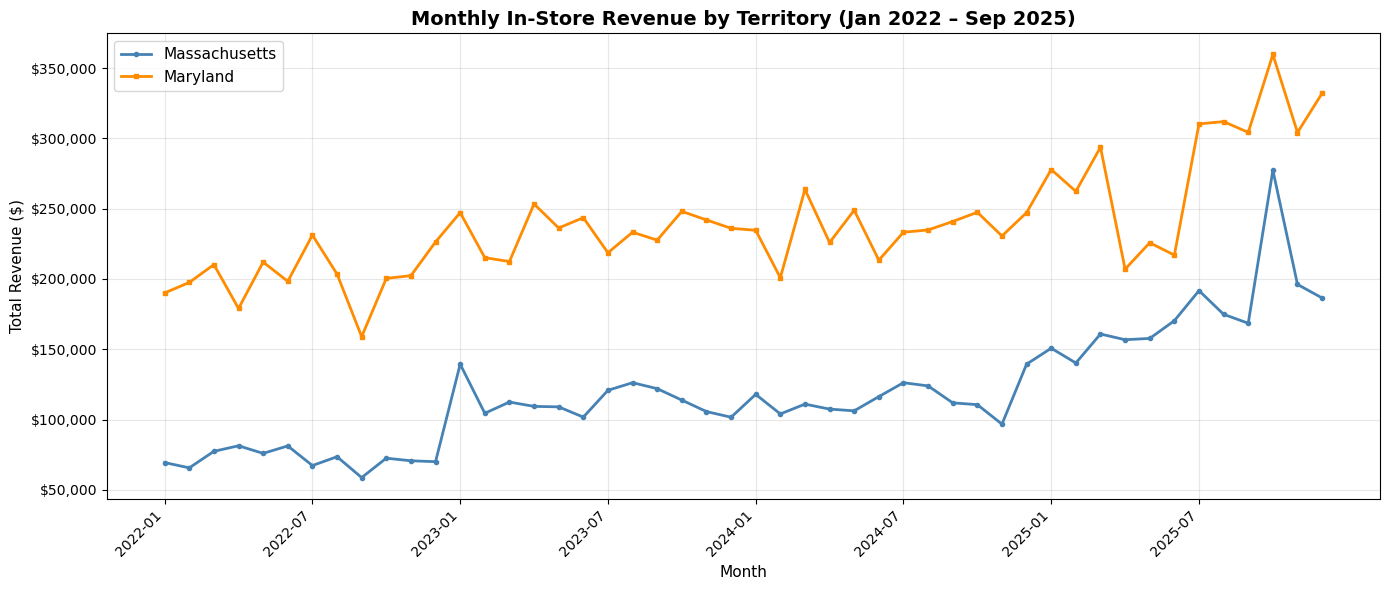


Chart type: Line chart — best for showing revenue trends over time


In [17]:
# CHART 1 Monthly Revenue Over Time by Territory 
ma_monthly = monthly_revenue[monthly_revenue['State'] == 'Massachusetts'].copy()
md_monthly = monthly_revenue[monthly_revenue['State'] == 'Maryland'].copy()

ma_monthly['Month_str'] = ma_monthly['Month'].astype(str)
md_monthly['Month_str'] = md_monthly['Month'].astype(str)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ma_monthly['Month_str'], ma_monthly['Total Revenue'], label='Massachusetts', color='steelblue', linewidth=2, marker='o', markersize=3)
ax.plot(md_monthly['Month_str'], md_monthly['Total Revenue'], label='Maryland', color='darkorange', linewidth=2, marker='s', markersize=3)

ax.set_title('Monthly In-Store Revenue by Territory (Jan 2022 – Sep 2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Total Revenue ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Show every 6th label to avoid crowding
tick_positions = range(0, len(ma_monthly), 6)
ax.set_xticks([ma_monthly['Month_str'].iloc[i] for i in tick_positions])
plt.xticks(rotation=45, ha='right')

ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nChart type: Line chart — best for showing revenue trends over time')

### Result
- Maryland consistently generates higher monthly revenue than Massachusetts throughout the data period.
- Maryland revenue ranges from 170K in early 2022 up to 360K by late 2025, showing strong growth over the full period. Massachusetts grew from 60K to over 270K an even stronger relative growth rate.

### Question 3 Store Performance Rankings

How would you rank the sales performance of each store in each territory? Which are the top performers?

In [13]:
# Total revenue per store merged with store info
store_revenue = sales_with_state.groupby(['Store ID', 'State'])['Sale Amount'].agg(
    Total_Revenue='sum',
    Num_Transactions='count',
    Avg_Transaction='mean'
).reset_index()

store_revenue = store_revenue.merge(territory_stores[['Store ID', 'Store Location']], on='Store ID')
store_revenue['Rank'] = store_revenue.groupby('State')['Total_Revenue'].rank(ascending=False).astype(int)
store_revenue = store_revenue.sort_values(['State', 'Rank'])

print('MASSACHUSETTS — Store Rankings')
ma_rank = store_revenue[store_revenue['State'] == 'Massachusetts'][['Rank', 'Store ID', 'Store Location', 'Total_Revenue', 'Num_Transactions', 'Avg_Transaction']]
ma_rank['Total_Revenue'] = ma_rank['Total_Revenue'].map('${:,.2f}'.format)
ma_rank['Avg_Transaction'] = ma_rank['Avg_Transaction'].map('${:.2f}'.format)
print(ma_rank.to_string(index=False))

print('\n MARYLAND — Store Rankings')
md_rank = store_revenue[store_revenue['State'] == 'Maryland'][['Rank', 'Store ID', 'Store Location', 'Total_Revenue', 'Num_Transactions', 'Avg_Transaction']]
md_rank['Total_Revenue'] = md_rank['Total_Revenue'].map('${:,.2f}'.format)
md_rank['Avg_Transaction'] = md_rank['Avg_Transaction'].map('${:.2f}'.format)
print(md_rank.to_string(index=False))

MASSACHUSETTS — Store Rankings
 Rank  Store ID Store Location Total_Revenue  Num_Transactions Avg_Transaction
    1       817      Worcester   $602,183.44              4477         $134.51
    2       807     Leominster   $338,009.10              2293         $147.41
    3       810      Nantucket   $335,547.81              2272         $147.69
    4       814   Provincetown   $328,860.51              2310         $142.36
    5       812    Northampton   $322,039.24              2258         $142.62
    6       806        Holyoke   $320,516.53              2168         $147.84
    7       816     Somerville   $312,873.59              2174         $143.92
    8       804      Haverhill   $305,762.60              2287         $133.70
    9       809           Lynn   $302,049.65              2118         $142.61
   10       813     Pittsfield   $301,281.50              2172         $138.71
   11       811    New Bedford   $295,443.42              2203         $134.11
   12       730      

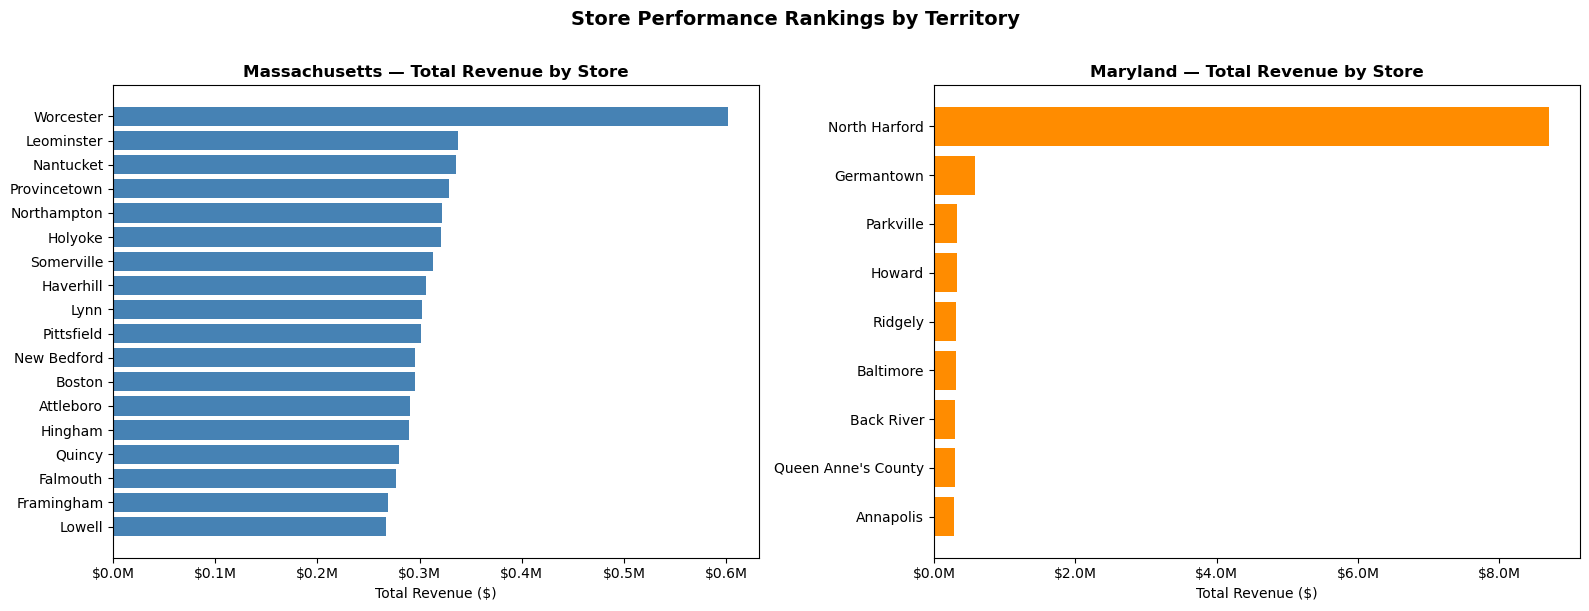

Chart type: Horizontal bar chart — best for comparing store level performance across a category


In [16]:
# CHART 2 Store Revenue Comparison 
store_rev_raw = sales_with_state.groupby(['Store ID', 'State'])['Sale Amount'].sum().reset_index()
store_rev_raw = store_rev_raw.merge(territory_stores[['Store ID', 'Store Location']], on='Store ID')

ma_bars = store_rev_raw[store_rev_raw['State'] == 'Massachusetts'].sort_values('Sale Amount', ascending=False)
md_bars = store_rev_raw[store_rev_raw['State'] == 'Maryland'].sort_values('Sale Amount', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Massachusetts
axes[0].barh(ma_bars['Store Location'], ma_bars['Sale Amount'], color='steelblue')
axes[0].set_title('Massachusetts — Total Revenue by Store', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Revenue ($)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].invert_yaxis()

# Maryland
axes[1].barh(md_bars['Store Location'], md_bars['Sale Amount'], color='darkorange')
axes[1].set_title('Maryland — Total Revenue by Store', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Revenue ($)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[1].invert_yaxis()

plt.suptitle('Store Performance Rankings by Territory', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Chart type: Horizontal bar chart — best for comparing store level performance across a category')

### Results
- Maryland top performer - Store 736 (North Harford) - by far the highest revenue store in either territory at 8.7M, an outlier compared to all other stores.
- Massachusetts top performer - Store 817 (Worcester) - leads MA with 602K.

### Question 4 Top Customers by Territory

Comparing the RewardsID from sales data with cust_id from the customer list, who were the top customers in each territory?

In [18]:
# Only keep rewards transactions 
rewards_sales = sales_with_state[sales_with_state['RewardsID'].notna()].copy()
rewards_sales['RewardsID'] = rewards_sales['RewardsID'].astype(int)
customer_list['cust_id'] = customer_list['cust_id'].astype(int)

# Total spend per RewardsID per State
top_cust = rewards_sales.groupby(['RewardsID', 'State'])['Sale Amount'].agg(
    Total_Spend='sum',
    Transactions='count'
).reset_index()

# Merge with customer names
top_cust = top_cust.merge(customer_list[['cust_id', 'name']], left_on='RewardsID', right_on='cust_id', how='left')

print('TOP 10 CUSTOMERS — Massachusetts')
ma_cust = top_cust[top_cust['State'] == 'Massachusetts'].sort_values('Total_Spend', ascending=False).head(10)
ma_cust['Total_Spend'] = ma_cust['Total_Spend'].map('${:,.2f}'.format)
print(ma_cust[['name', 'RewardsID', 'Total_Spend', 'Transactions']].to_string(index=False))

print('\nTOP 10 CUSTOMERS — Maryland')
md_cust = top_cust[top_cust['State'] == 'Maryland'].sort_values('Total_Spend', ascending=False).head(10)
md_cust['Total_Spend'] = md_cust['Total_Spend'].map('${:,.2f}'.format)
print(md_cust[['name', 'RewardsID', 'Total_Spend', 'Transactions']].to_string(index=False))

TOP 10 CUSTOMERS — Massachusetts
           name  RewardsID Total_Spend  Transactions
Beverly Crusher        292   $4,758.92            14
   Tracy Jordan        384   $4,197.55            14
     Stanley H.         47   $3,979.73            12
  Monica Geller          3   $3,966.91            15
   Mellie Grant        188   $3,948.41            10
  Julian Bashir        300   $3,883.60            12
        Mike E.         17   $3,788.67            11
    Kaylee Frye        316   $3,725.87            13
    Nate Jacobs        344   $3,569.36            10
   Pamela James        178   $3,523.01            12

TOP 10 CUSTOMERS — Maryland
           name  RewardsID Total_Spend  Transactions
     Cole Brown        180   $7,602.28            26
  Donna Hayward        355   $7,081.17            24
 Avon Barksdale        467   $6,172.68            27
     Trent Lane         99   $6,076.89            22
      Magnitude         75   $5,916.81            20
          Fezco        349   $5,795.7

### Results
- Maryland top customer - Cole Brown (RewardsID 180) - spent 7,602.28 across 26 transactions.
- Massachusetts top customer - Beverly Crusher (RewardsID 292) -  spent 4,758.92 across 14 transactions.
- In Massachusetts, rewards members average 139.51 per transaction vs non-rewards 136.12 - rewards members spend more per visit.
- In Maryland, rewards vs non rewards average is nearly identical (128.08 vs 127.99).
- Most importantly - 89.6% of all territory transactions - 117,817 out of 131,476 -  have NO rewards ID. This means the vast majority of customers are completely unknown to us. Growing rewards membership is the single biggest untapped opportunity in both territories.

check result befor i go ques 5